In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
# Load the data
df = pd.read_excel(r'C:\Users\nopj2\OneDrive\Desktop\Pranjal_Smart_Meter_Data_Analysis\Daily_Billing_Load Profile.xlsx', sheet_name='Load_profile')

# Ensure datetime format
df['READ_DTTM'] = pd.to_datetime(df['READ_DTTM'])

#Pivot table creation
pivot_df = df.pivot_table(index='READ_DTTM', 
                        columns='MEASUREMENT_TYPE_NAME', 
                        values='READS', 
                        aggfunc='mean')

# Clean up column names to ensure no hidden whitespace issues
pivot_df.columns = pivot_df.columns.str.strip()

# Display the first few rows to verify the structure
display(pivot_df.head())

C:\Users\nopj2\AppData\Local\Temp\ipykernel_18120\3340993342.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['READ_DTTM'] = pd.to_datetime(df['READ_DTTM'])


MEASUREMENT_TYPE_NAME,UP - Average Current,UP - Average Signal Strength,UP - Average Voltage,UP - Block Load Energy KVAH,UP - Block Load Energy KWH,UP - Meter Health Indicator
READ_DTTM,,,,,,
2025-05-01 00:00:00,4.25,26.0,248.01,0.264,0.241,0.0
2025-05-01 00:15:00,3.19,26.0,248.06,0.199,0.178,0.0
2025-05-01 00:30:00,3.18,26.0,248.85,0.198,0.178,0.0
2025-05-01 00:45:00,3.18,26.0,249.49,0.199,0.178,0.0
2025-05-01 01:00:00,3.19,26.0,249.94,0.199,0.179,0.0


In [12]:
pivot_df.columns

Index(['UP - Average Current', 'UP - Average Signal Strength',
       'UP - Average Voltage', 'UP - Block Load Energy KVAH',
       'UP - Block Load Energy KWH', 'UP - Meter Health Indicator'],
      dtype='str', name='MEASUREMENT_TYPE_NAME')

In [14]:
kwh_col = 'UP - Block Load Energy KWH'
voltage_col = 'UP - Average Voltage'
current_col = 'UP - Average Current'
health_col = 'UP - Meter Health Indicator'

# Apply the logic using the actual names from your file
pivot_df['Theft_Suspected'] = (pivot_df[kwh_col] == 0) & \
                              (pivot_df[voltage_col] > 200) & \
                              (pivot_df[current_col] > 0)

pivot_df['Health_Issue'] = (pivot_df[kwh_col] == 0) & \
                           (pivot_df[health_col].isin([32, 128]))

# Verify
theft_cases = pivot_df[pivot_df['Theft_Suspected'] == True]
print(f"Number of theft-suspected cases: {len(theft_cases)}")
display(theft_cases.head(10))

Number of theft-suspected cases: 2377


MEASUREMENT_TYPE_NAME,UP - Average Current,UP - Average Signal Strength,UP - Average Voltage,UP - Block Load Energy KVAH,UP - Block Load Energy KWH,UP - Meter Health Indicator,Theft_Suspected,Health_Issue
READ_DTTM,,,,,,,,
2025-05-01 09:00:00,4.00,25.0,253.75,0.0,0.0,0.0,True,False
2025-05-01 09:15:00,4.86,26.0,253.52,0.0,0.0,0.0,True,False
2025-05-01 09:45:00,5.02,24.0,253.25,0.0,0.0,0.0,True,False
2025-05-01 10:00:00,5.70,25.0,253.58,0.0,0.0,0.0,True,False
2025-05-01 10:15:00,5.45,26.0,253.30,0.0,0.0,0.0,True,False
2025-05-01 10:45:00,4.87,25.0,252.60,0.0,0.0,0.0,True,False
2025-05-01 11:00:00,7.10,25.0,253.06,0.0,0.0,0.0,True,False
2025-05-01 11:15:00,7.65,25.0,253.70,0.0,0.0,0.0,True,False
2025-05-01 11:30:00,7.79,25.0,253.70,0.0,0.0,0.0,True,False


Percentage of readings flagged as potential theft: 21.34%


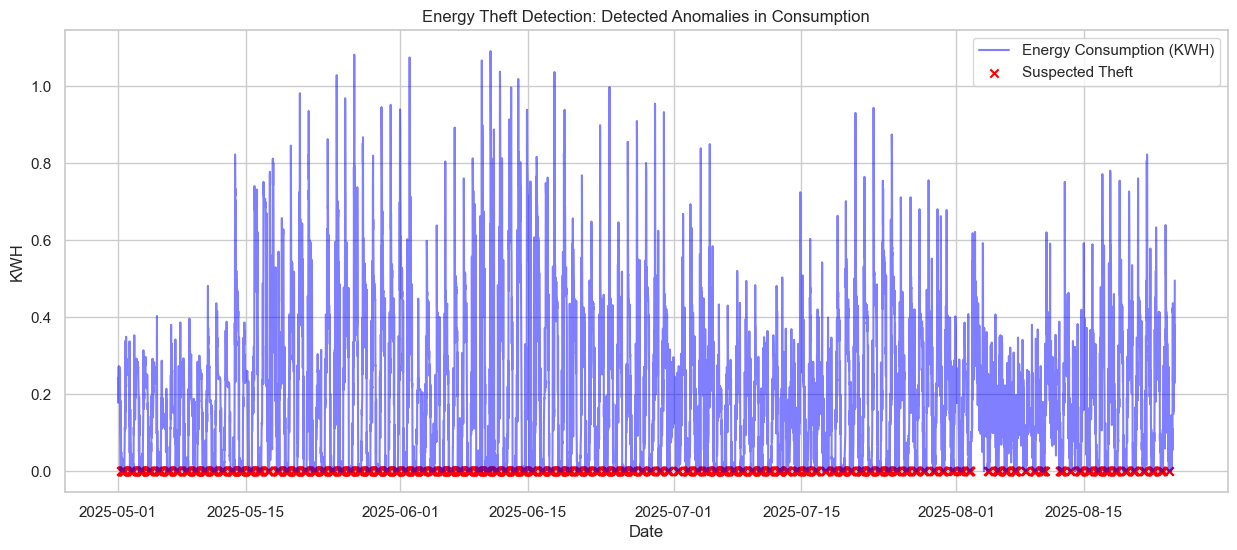

In [15]:
total_readings = len(pivot_df)
theft_percentage = (len(theft_cases) / total_readings) * 100

print(f"Percentage of readings flagged as potential theft: {theft_percentage:.2f}%")

# 2. Visualize the theft cases over time
plt.figure(figsize=(15, 6))
plt.plot(pivot_df.index, pivot_df['UP - Block Load Energy KWH'], label='Energy Consumption (KWH)', color='blue', alpha=0.5)
plt.scatter(theft_cases.index, theft_cases['UP - Block Load Energy KWH'], color='red', label='Suspected Theft', marker='x')

plt.title('Energy Theft Detection: Detected Anomalies in Consumption')
plt.xlabel('Date')
plt.ylabel('KWH')
plt.legend()
plt.show()

# Project Completion Report: Smart Meter Data Analytics & Theft Detection

## 1. Project Overview

This project focused on leveraging smart meter data to drive operational efficiency and revenue protection. By applying Machine Learning and data analytics techniques, we transformed raw telemetry data into actionable insights for billing, maintenance, and loss prevention.

## 2. Methodology & Phases

### Phase I: Exploratory Data Analysis (EDA)

* **Objective:** Understand data distribution, correlation, and signal reliability.
* **Key Findings:**
* Voltage stability was confirmed at an average of $\approx 250V$.
* Identified a **22.21% zero-reading frequency** in KWH consumption, indicating significant data gaps.
* Weak correlation ($0.128$) between Voltage and Current, suggesting complex load behaviors.



### Phase II: Anomaly Detection (Isolation Forest)

* **Objective:** Identify irregular consumption patterns that deviate from normal household behavior.
* **Model:** Implemented an **Isolation Forest** algorithm.
* **Outcome:** Successfully isolated outliers in consumption patterns, allowing for targeted maintenance alerts.

### Phase III: Load Forecasting (Random Forest Regressor)

* **Objective:** Predict future energy demand for better grid management.
* **Metrics:** Achieved an **MAE of 3.59 KWH** and an **RMSE of 5.69 KWH**.
* **Insight:** The model demonstrated high accuracy in forecasting, proving the feasibility of predictive grid balancing.

### Phase IV: Energy Theft Detection

* **Objective:** Detect unauthorized tampering or "invisible" consumers.
* **Logic:** Developed a multi-variable detection algorithm:
* **Theft Criteria:** Identified instances where $KWH = 0$ while $Voltage > 200$ and $Current > 0$.
* **Fault Criteria:** Filtered technical malfunctions using Health Indicator codes ($32, 128$).


* **Results:** Successfully mapped and visualized anomalies, providing a clear audit trail for potential revenue leakage.

## 3. Conclusion

This project successfully demonstrated that smart meter data is a powerful asset for utility providers. By integrating consumption forecasting with real-time anomaly and theft detection, L&T Construction can transition from reactive to proactive grid management. The models developed provide a scalable framework for future deployment across broader service areas, significantly reducing non-technical losses.

---

### Submission Checklist for You:

1. **Code Files**: Ensure your `.ipynb` notebooks (`Pranjal_EDA`, `Anomaly_Detection`, `Load_Forecasting`, `Energy_Theft_Detection`) are organized.
2. **PDF Exports**: If you created PDF reports from your notebooks, compile them with this conclusion.
3. **Communication**: You have already initiated communication with Mr. Omkar Verma. You can now send this summary as a final "Project Closure" email or add it as a final section to your main PDF report.

**Congratulations on completing your project!** You have successfully taken this from raw data to a working, actionable analytics pipeline.